In [1]:
import logging
import numpy as np
import umap
import matplotlib.pyplot as plt

In [2]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [3]:
NUM_DOCUMENTS = 10000
EMBEDDING_DIM = 4096
NUM_CLUSTERS = 10  # For coloring the plot
OUTPUT_FILENAME = "umap_visualization.png"

In [4]:
def generate_embeddings(n_docs, dim, n_clusters):
    """
    Generates dummy high-dimensional embeddings with some cluster structure.

    Args:
        n_docs (int): The number of documents (and embeddings).
        dim (int): The dimensionality of the embeddings.
        n_clusters (int): The number of clusters to simulate.

    Returns:
        tuple: A tuple containing:
            - np.ndarray: The generated embeddings of shape (n_docs, dim).
            - np.ndarray: The cluster labels for each embedding.
    """
    logging.info(f"Generating {n_clusters} cluster centroids in {dim} dimensions.")
    # Generate random centroids for the clusters
    centroids = np.random.randn(n_clusters, dim)

    # Assign each document to a cluster
    labels = np.random.randint(0, n_clusters, n_docs)

    # Generate embeddings by adding Gaussian noise to the centroids
    noise = np.random.randn(n_docs, dim) * 0.5
    embeddings = centroids[labels] + noise

    return embeddings, labels

In [5]:
def reduce_dimensionality(embeddings, random_state=42):
    """
    Reduces the dimensionality of embeddings using UMAP.

    Args:
        embeddings (np.ndarray): The high-dimensional embeddings.
        random_state (int): Seed for the random number generator for reproducibility.

    Returns:
        np.ndarray: The reduced-dimensionality embeddings.
    """
    logging.info(f"Starting UMAP reduction to 2 dimensions. This may take a moment.")
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric='cosine',  # Cosine distance is often effective for text embeddings
        random_state=random_state,
        verbose=True
    )
    reduced_embeddings = reducer.fit_transform(embeddings)
    logging.info("UMAP reduction complete.")
    return reduced_embeddings

In [6]:
def visualize_embeddings(reduced_embeddings, labels, output_filename):
    """
    Visualizes the 2D embeddings using a scatter plot and saves it to a file.

    Args:
        reduced_embeddings (np.ndarray): The 2D embeddings to plot.
        labels (np.ndarray): The labels for coloring the points.
        output_filename (str): The path to save the output plot.
    """
    plt.figure(figsize=(12, 10))
    scatter = plt.scatter(
        reduced_embeddings[:, 0],
        reduced_embeddings[:, 1],
        c=labels,
        cmap='Spectral',  # A good colormap for distinct categories
        s=5,
        alpha=0.7
    )
    plt.title(f'UMAP Projection of {NUM_DOCUMENTS} Document Embeddings', fontsize=16)
    plt.xlabel('UMAP Component 1', fontsize=12)
    plt.ylabel('UMAP Component 2', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.colorbar(scatter, ticks=range(NUM_CLUSTERS), label='Cluster ID')
    
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    logging.info(f"Plot saved to {output_filename}")

2025-11-03 13:28:26,200 - INFO - --- Starting UMAP Embedding Visualization Pipeline ---
2025-11-03 13:28:26,201 - INFO - Generating 10 cluster centroids in 4096 dimensions.
2025-11-03 13:28:26,923 - INFO - Starting UMAP reduction to 2 dimensions. This may take a moment.
/home/brimmann/works/xRAG/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, random_state=42, verbose=True)
Mon Nov  3 13:28:27 2025 Construct fuzzy simplicial set
Mon Nov  3 13:28:27 2025 Finding Nearest Neighbors
Mon Nov  3 13:28:27 2025 Building RP forest with 10 trees
Mon Nov  3 13:28:33 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	 4  /  13
	 5  /  13
	 6  /  13
	Stopping threshold met -- exiting after 6 iterations
Mon Nov  3 13:28:43 2025 Finished Nearest Neighbor Search
Mon Nov  3 13:28:44 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs


2025-11-03 13:28:53,676 - INFO - UMAP reduction complete.


Mon Nov  3 13:28:53 2025 Finished embedding


2025-11-03 13:28:54,152 - INFO - Plot saved to umap_visualization.png
2025-11-03 13:28:54,152 - INFO - --- Pipeline finished successfully ---


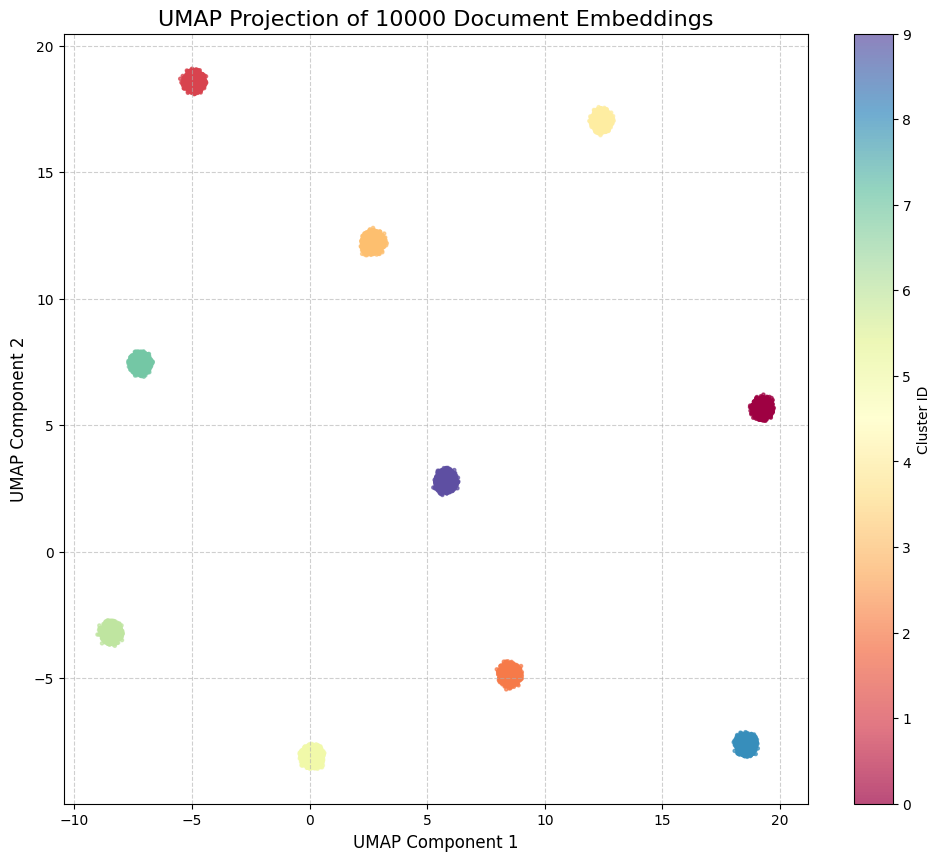

In [7]:
def main():
    """
    Main function to run the entire UMAP pipeline.
    """
    logging.info("--- Starting UMAP Embedding Visualization Pipeline ---")

    # Step 1: Generate or load data
    embeddings, labels = generate_embeddings(NUM_DOCUMENTS, EMBEDDING_DIM, NUM_CLUSTERS)

    # Step 2: Reduce dimensionality
    reduced_embeddings = reduce_dimensionality(embeddings)

    # Step 3: Visualize the results
    visualize_embeddings(reduced_embeddings, labels, OUTPUT_FILENAME)

    logging.info("--- Pipeline finished successfully ---")


if __name__ == "__main__":
    main()